In [2]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker",
    "The team won the cricket match by chasing the target",
    "Fielding plays a crucial role in cricket matches",

    # Cooking (3)
    "The chef prepared a delicious pasta dish",
    "Baking requires precise measurements of ingredients",
    "Frying vegetables enhances their flavor",

    # Cybersecurity (3)
    "Strong passwords are essential for online security",
    "Cyber attacks can compromise sensitive data",
    "Encryption protects information from unauthorized access"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (10, 384)


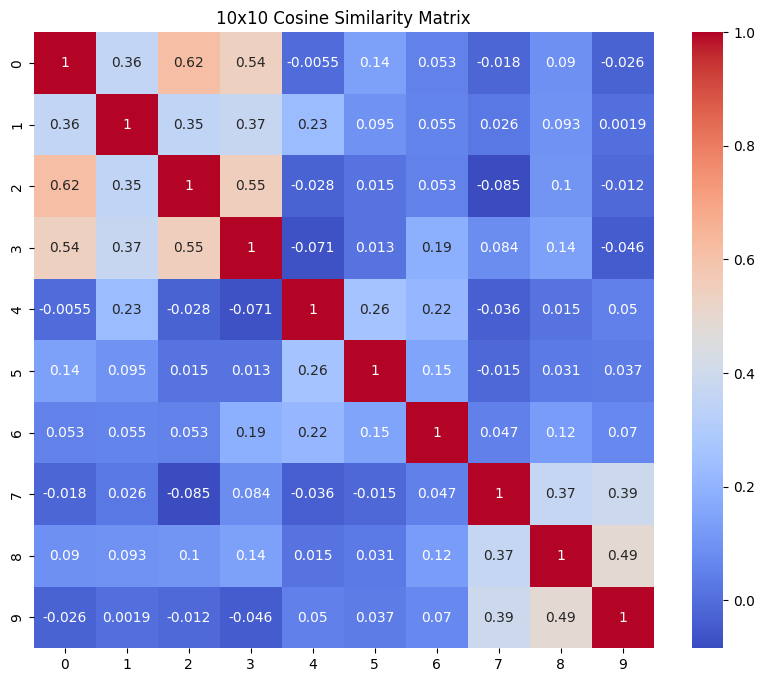

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:")

for idx in top_indices:
    print(f"\nSentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

Sentence: The bowler delivered a perfect yorker
Similarity Score: 0.5481
